https://www.kaggle.com/datasets/prokshitha/home-value-insights

## 1. Analyze the situation and questions

1. What's the real problem?
- Find the price of the houses are difficult, and waste a lot of time and money, so we need a model to predict the price
2. What's the final objective?
- Predict the number of houses price
3. How the model will be used?

## 2. Get the data

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dataset = pd.read_csv('../../datasets/housing2_project4.csv')

Features:

Square_Footage: The size of the house in square feet. Larger homes typically have higher prices.

Num_Bedrooms: The number of bedrooms in the house. More bedrooms generally increase the value of a home.

Num_Bathrooms: The number of bathrooms in the house. Houses with more bathrooms are typically priced higher.

Year_Built: The year the house was built. Older houses may be priced lower due to wear and tear.

Lot_Size: The size of the lot the house is built on, measured in acres. Larger lots tend to add value to a property.

Garage_Size: The number of cars that can fit in the garage. Houses with larger garages are usually more expensive.

Neighborhood_Quality: A rating of the neighborhood’s quality on a scale of 1-10, where 10 indicates a high-quality 
neighborhood. Better neighborhoods usually command higher prices.

House_Price (Target Variable): The price of the house, which is the dependent variable you aim to predict.

## 3. EDA parts

Informations:

- Shape: 1000, 8
- Scale Awareness problem

#### 3.1 GERAL VISUALIZE

In [34]:
# 3.1 GERAL ANALYZE OF THE DATA HEAD

dataset.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [35]:
# 3.1.2 SHAPE

dataset.shape

(1000, 8)

In [36]:
# 3.1.3 DESCIBRE
dataset.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


#### 3.2 STRUCTURE AND QUALITY OF THE FEATURES

In [37]:
# 3.2.1 CONSTANT FEATURES

dataset.nunique()

Square_Footage           894
Num_Bedrooms               5
Num_Bathrooms              3
Year_Built                73
Lot_Size                1000
Garage_Size                3
Neighborhood_Quality      10
House_Price             1000
dtype: int64

In [38]:
# 3.2.2 REDUDANT FEATURES
dataset.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [39]:
# 3.2.3 DUPLICATES

dataset.duplicated().sum()

np.int64(0)

In [40]:
# 3.2.4 CARDINALITY

dataset.nunique()

Square_Footage           894
Num_Bedrooms               5
Num_Bathrooms              3
Year_Built                73
Lot_Size                1000
Garage_Size                3
Neighborhood_Quality      10
House_Price             1000
dtype: int64

#### 3.3 TYPE OF THE DATA

In [41]:
# 3.3.1 CATEGORIAL

dataset.dtypes

Square_Footage            int64
Num_Bedrooms              int64
Num_Bathrooms             int64
Year_Built                int64
Lot_Size                float64
Garage_Size               int64
Neighborhood_Quality      int64
House_Price             float64
dtype: object

In [42]:
# 3.3.2 TIME FEATURE
dataset.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


#### 3.4 MISSING AND INVALID DATA

In [43]:
# 3.4.1 NULL VALUES

dataset.isnull().sum()

Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64

In [44]:
# 3.4.2

negative = (dataset < 0).sum()
negative

Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64

In [45]:
# 3.4.3 CENSORING

dataset.tail()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
995,3261,4,1,1978,2.165110,2,10,701493.997069
996,3179,1,2,1999,2.977123,1,10,683723.160704
997,2606,4,2,1962,4.055067,0,2,572024.023634
998,4723,5,2,1950,1.930921,0,7,964865.298639
999,3268,4,2,1983,3.108790,2,2,742599.253332


#### 3.5 DISTRIBUTION OF THE DATA

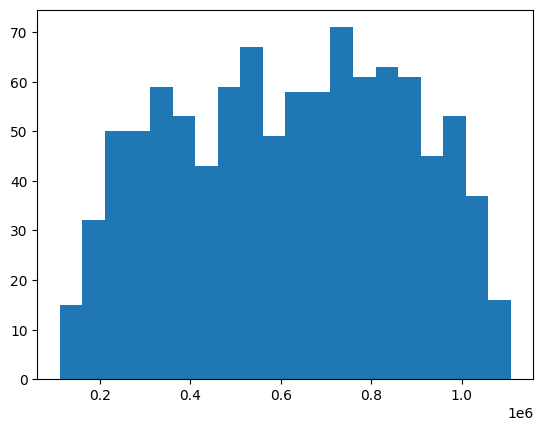

In [53]:
# 3.5.1 SKEWED DATA


plt.hist(dataset['House_Price'], bins = 20);


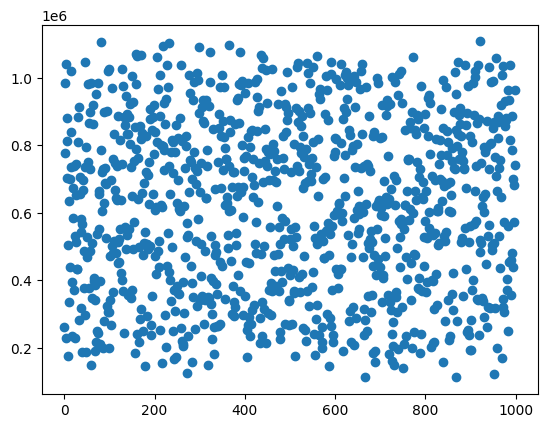

In [58]:
# 3.5.2 OUTLIERS
dataset['index'] = range(1000)


plt.scatter(x=dataset['index'], y= dataset['House_Price']);

In [59]:
dataset.drop(columns=['index'], inplace= True)
dataset

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06
...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10,7.014940e+05
996,3179,1,2,1999,2.977123,1,10,6.837232e+05
997,2606,4,2,1962,4.055067,0,2,5.720240e+05
998,4723,5,2,1950,1.930921,0,7,9.648653e+05


#### 3.6 CORRELATION FEATURES

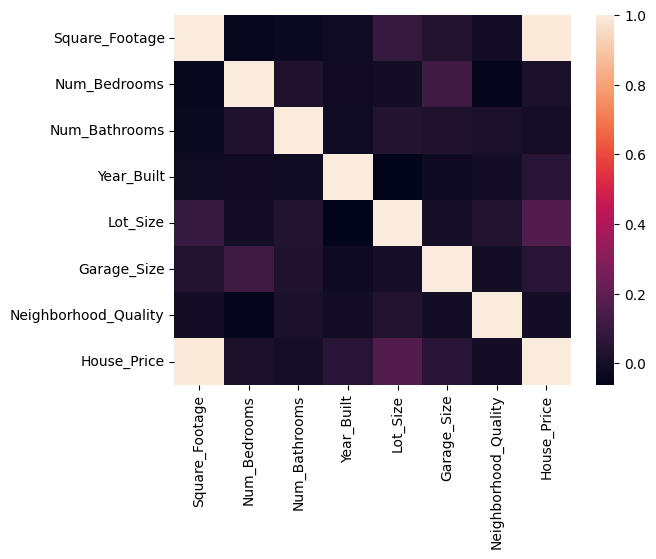

In [62]:
# 3.6.1 CORRELATION

dataset_corr = dataset.corr()
sns.heatmap(dataset_corr);

#### 3.7 MODEL SENSITVITY

In [63]:
# 3.7.1 SCALE AWARENESS

dataset.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


## 4. PREPROCESSING DATA AND SPLIT DATA

In [69]:
X = dataset.drop(columns=['House_Price'])
X

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality
0,1360,2,1,1981,0.599637,0,5
1,4272,3,3,2016,4.753014,1,6
2,3592,1,2,2016,3.634823,0,9
3,966,1,2,1977,2.730667,1,8
4,4926,2,1,1993,4.699073,0,8
...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10
996,3179,1,2,1999,2.977123,1,10
997,2606,4,2,1962,4.055067,0,2
998,4723,5,2,1950,1.930921,0,7


In [70]:
y = dataset[['House_Price']]
y

,House_Price
0,2.623829e+05
1,9.852609e+05
2,7.779774e+05
3,2.296989e+05
4,1.041741e+06
...,...
995,7.014940e+05
996,6.837232e+05
997,5.720240e+05
998,9.648653e+05


In [74]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)
X


array([[-1.15980323, -0.69383623, -1.18669921, ..., -1.67927849,
        -1.25465753, -0.21312613],
       [ 1.16072443,  0.00700845,  1.25255918, ...,  1.52238989,
        -0.02700828,  0.13342042],
       [ 0.61884297, -1.39468091,  0.03292999, ...,  0.66042215,
        -1.25465753,  1.17306009],
       ...,
       [-0.16688515,  0.70785312,  0.03292999, ...,  0.98437109,
        -1.25465753, -1.25276579],
       [ 1.52011933,  1.4086978 ,  0.03292999, ..., -0.65304553,
        -1.25465753,  0.47996698],
       [ 0.36065239,  0.70785312,  0.03292999, ...,  0.25492526,
         1.20064096, -1.25276579]], shape=(1000, 7))

In [81]:
from sklearn.model_selection import train_test_split


X_train, x_test, Y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

## 5. MODEL SELECT AND TRAIN

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# TRAIN
model = LinearRegression()
model.fit(X_train, Y_train)

# GET THE ACCURACY OF TRAIN
y_preds_train = model.predict(X_train)
r2_train = r2_score(Y_train, y_preds_train)
print(f"A accuracy do modelo no treino foi de (R2) foi de: {r2_train*100:.2f}%")

# GET THE ACCURACY OF RESR
y_preds_test = model.predict(x_test)
r2_test = r2_score(y_test, y_preds_test)
print(f"A accuracy do modelo no test foi de (R2) foi de: {r2_test*100:.2f}%")




A accuracy do modelo no treino foi de (R2) foi de: 99.85%
A accuracy do modelo no test foi de (R2) foi de: 99.84%
